In [1]:
#Bayesian Linear Regression demo (conjugate Normal-Inverse-Gamma)

import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(1663)

#Simulate data
n = 120
x = np.random.uniform(-2, 2, size=n)

beta0_true = 1.25
beta1_true = 2.10
sigma_true = 1.00

y = beta0_true + beta1_true * x + np.random.normal(0, sigma_true, size=n)

#Design matrix with intercept
X = np.column_stack([np.ones(n), x])
p = X.shape[1]

#OLS baseline (closed form)
XtX = X.T @ X
Xty = X.T @ y
beta_ols = np.linalg.solve(XtX, Xty)
resid = y - X @ beta_ols
s2_ols = (resid @ resid) / (n - p)

print("OLS estimates")
print(f"  beta0_hat = {beta_ols[0]}")
print(f"  beta1_hat = {beta_ols[1]}")
print(f"  sigma_hat = {np.sqrt(s2_ols)}\n")

OLS estimates
  beta0_hat = 1.2852696878008296
  beta1_hat = 1.921801092584972
  sigma_hat = 1.0658275106585187



In [3]:
#Bayesian regression setup
#Conjugate prior:
#   beta | sigma^2 ~ N(b0, sigma^2 * V0)
#   sigma^2 ~ Inv-Gamma(a0, b0)  (shape a0, scale b0)

#Choose a weakly informative prior.
b0 = np.array([0.0, 0.0])             #prior mean
V0 = np.diag([10.0**2, 10.0**2])      #prior covariance scale (big = weak)
V0_inv = np.linalg.inv(V0)

a0 = 2.0   #small-ish, but > 1 so mean exists
b0_ig = 2.0

#Posterior calculations (closed form)
Vn = np.linalg.inv(V0_inv + XtX)
bn = Vn @ (V0_inv @ b0 + Xty)

an = a0 + n / 2.0

#Compute b_n (scale for Inv-Gamma) carefully
yTy = y @ y
b0_quad = b0 @ V0_inv @ b0
bn_quad = bn @ np.linalg.inv(Vn) @ bn
bn_ig = b0_ig + 0.5 * (yTy + b0_quad - bn_quad)

#Posterior:
#   sigma^2 | y ~ Inv-Gamma(an, bn_ig)
#   beta | sigma^2, y ~ N(bn, sigma^2 * Vn)

print("Bayesian posterior (conjugate)")
print(f"  bn (posterior mean of beta) = [{bn[0]:.3f}, {bn[1]:.3f}]")
print(f"  an (IG shape) = {an:.3f}")
print(f"  bn_ig (IG scale) = {bn_ig:.3f}\n")

#Posterior mean of sigma^2 (exists if an > 1)
sigma2_mean = bn_ig / (an - 1.0)
print(f"Posterior mean sigma = {np.sqrt(sigma2_mean):.3f}\n")

#Draw posterior samples
S = 5000

#Sample sigma^2 from Inv-Gamma by sampling 1/sigma^2 from Gamma
#If sigma^2 ~ InvGamma(a, b), then 1/sigma^2 ~ Gamma(a, scale=1/b)
sigma2_samps = 1.0 / st.gamma.rvs(an, scale=1.0 / bn_ig, size=S)

#Sample beta conditional on sigma^2
beta_samps = np.zeros((S, p))
L = np.linalg.cholesky(Vn)
z = np.random.normal(size=(S, p))
for s in range(S):
    beta_samps[s] = bn + np.sqrt(sigma2_samps[s]) * (z[s] @ L.T)

beta0_s = beta_samps[:, 0]
beta1_s = beta_samps[:, 1]
sigma_s = np.sqrt(sigma2_samps)

def ci(a, level=0.95):
    lo = (1 - level) / 2
    hi = 1 - lo
    return np.quantile(a, [lo, hi])

b0_ci = ci(beta0_s)
b1_ci = ci(beta1_s)
sig_ci = ci(sigma_s)

print("95% credible intervals")
print(f"  beta0: [{b0_ci[0]:.3f}, {b0_ci[1]:.3f}]  (true {beta0_true:.3f})")
print(f"  beta1: [{b1_ci[0]:.3f}, {b1_ci[1]:.3f}]  (true {beta1_true:.3f})")
print(f"  sigma: [{sig_ci[0]:.3f}, {sig_ci[1]:.3f}]  (true {sigma_true:.3f})\n")

Bayesian posterior (conjugate)
  bn (posterior mean of beta) = [1.285, 1.922]
  an (IG shape) = 62.000
  bn_ig (IG scale) = 69.050

Posterior mean sigma = 1.064

95% credible intervals
  beta0: [1.090, 1.475]  (true 1.250)
  beta1: [1.754, 2.086]  (true 2.100)
  sigma: [0.939, 1.210]  (true 1.000)



In [ ]:
#Posterior predictive
# y_new = x_new' beta + eps, eps ~ N(0, sigma^2)
x_grid = np.linspace(x.min(), x.max(), 200)
Xg = np.column_stack([np.ones_like(x_grid), x_grid])

# Predictive draws
pred_samps = np.zeros((S, len(x_grid)))
eps = np.random.normal(size=(S, len(x_grid)))
for s in range(S):
    mu = Xg @ beta_samps[s]
    pred_samps[s] = mu + eps[s] * sigma_s[s]

mu_samps = Xg @ beta_samps.T   # shape (len(x_grid), S)
mu_samps = mu_samps.T          # (S, len(x_grid))

mu_med = np.median(mu_samps, axis=0)
mu_lo, mu_hi = np.quantile(mu_samps, [0.025, 0.975], axis=0)

pred_lo, pred_hi = np.quantile(pred_samps, [0.025, 0.975], axis=0)

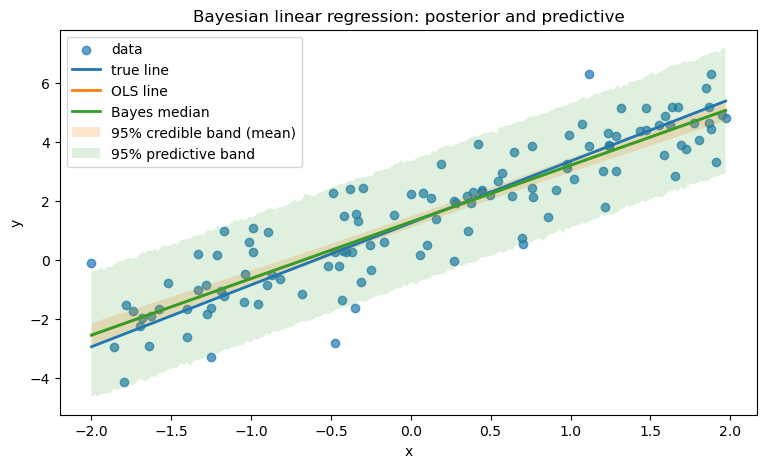

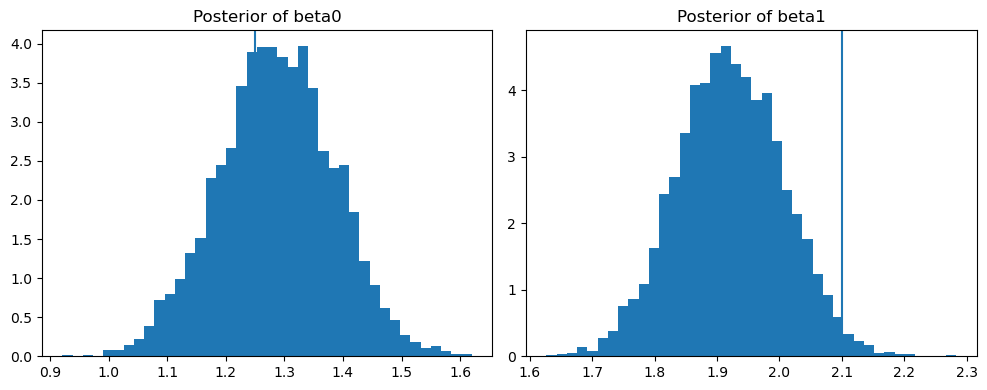

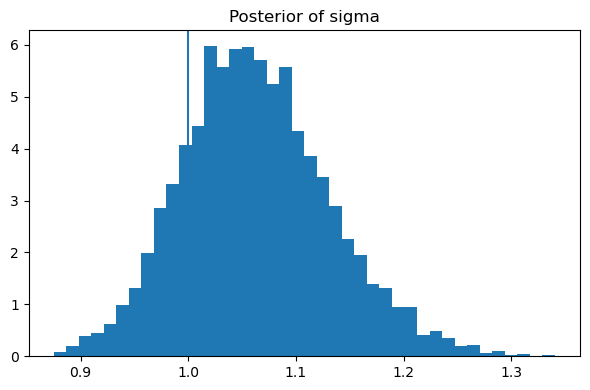

In [ ]:
#Plots
plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.7, label="data")
plt.plot(x_grid, beta0_true + beta1_true * x_grid, linewidth=2, label="true line")

#OLS line
plt.plot(x_grid, beta_ols[0] + beta_ols[1] * x_grid, linewidth=2, label="OLS line")

#Bayesian posterior median and intervals
plt.plot(x_grid, mu_med, linewidth=2, label="Bayes median")
plt.fill_between(x_grid, mu_lo, mu_hi, alpha=0.2, label="95% credible band (mean)")
plt.fill_between(x_grid, pred_lo, pred_hi, alpha=0.15, label="95% predictive band")

plt.title("Bayesian linear regression: posterior and predictive")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

#Coefficient posterior histograms
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(beta0_s, bins=40, density=True)
plt.axvline(beta0_true)
plt.title("Posterior of beta0")
plt.subplot(1, 2, 2)
plt.hist(beta1_s, bins=40, density=True)
plt.axvline(beta1_true)
plt.title("Posterior of beta1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(sigma_s, bins=40, density=True)
plt.axvline(sigma_true)
plt.title("Posterior of sigma")
plt.tight_layout()
plt.show()